# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "MariO Alfonso Valadez Hernandez"            
MATRICULA = "82357"         
DATASET_ASIGNADO = "migracion"   

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: MariO Alfonso Valadez Hernandez
Matrícula: 82357
Dataset asignado: migracion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\mario\Downloads\Big_Data_GitHub\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: migracion
Descripcion: Numero total de inmigrantes internacionales residiendo en el pais (personas)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,1990,57686,Asia
1,Afghanistan,AFG,1995,71522,Asia
2,Afghanistan,AFG,2000,75917,Asia
3,Afghanistan,AFG,2005,87314,Asia
4,Afghanistan,AFG,2010,102276,Asia
5,Afghanistan,AFG,2015,339432,Asia
6,Afghanistan,AFG,2020,144098,Asia
7,Afghanistan,AFG,2024,98110,Asia
8,Africa,OWID_AFR,1990,16176915,NaN
9,Africa,OWID_AFR,1995,16653698,NaN


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(2144, 5)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2144 entries, 0 to 2143
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   entity       2144 non-null   str  
 1   code         1960 non-null   str  
 2   year         2144 non-null   int64
 3   valor        2144 non-null   int64
 4   owid_region  1824 non-null   str  
dtypes: int64(2), str(3)
memory usage: 83.9 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    2.144000e+03
mean     4.987920e+06
std      1.998549e+07
min      1.080000e+02
25%      3.905450e+04
50%      2.187635e+05
75%      1.420072e+06
max      3.040218e+08
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           184
year             0
valor            0
owid_region    320
dtype: int64

**Interpretación (2-3 líneas):** El dataset contiene observaciones de países y una variable cuantitativa de número de inmigrantes. La serie abarca de 1990 a 2024, con datos en intervalos de cinco años; pueden existir valores nulos en algunas columnas o indicadores. Por ello, antes de calcular estadísticas se eliminaron los valores faltantes de `valor`.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [10]:
df_paises = df[df[config["filtro_paises"]].notna()]

numero_paises = df_paises["entity"].nunique()
anio = df_paises["year"].max()

datos_anio = df_paises[
    (df_paises["year"] == anio) &
    (df_paises["valor"].notna())
]

mayores = datos_anio.nlargest(10, "valor")[["entity", "year", "valor"]]
menores = datos_anio.nsmallest(10, "valor")[["entity", "year", "valor"]]

print("Países distintos:", numero_paises)
print("Año utilizado:", anio)

print("\n10 países con mayor valor:")
display(mayores)

print("\n10 países con menor valor:")
display(menores)

Países distintos: 228
Año utilizado: 2024

10 países con mayor valor:


,entity,year,valor
2015,United States,2024,52375047
719,Germany,2024,16750084
1655,Saudi Arabia,2024,13683841
2007,United Kingdom,2024,11845479
671,France,2024,9186757
1815,Spain,2024,8870527
303,Canada,2024,8805839
1999,United Arab Emirates,2024,8157000
111,Australia,2024,8111404
1575,Russia,2024,7605774



10 países con menor valor:


,entity,year,valor
1975,Tuvalu,2024,246
1591,Saint Helena,2024,492
2063,Vatican,2024,496
1615,Saint Pierre and Miquelon,2024,1008
1919,Tokelau,2024,1282
1263,Montserrat,2024,1402
1647,Sao Tome and Principe,2024,1955
439,Cuba,2024,2144
639,Falkland Islands,2024,2333
1735,Solomon Islands,2024,2469


**Interpretación:** En 2024 se identificaron 228 países. Estados Unidos tiene el mayor número de inmigrantes, mientras que Tuvalu presenta el menor entre los países con datos. El tamaño de los valores muestra una distribución muy desigual entre países.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [11]:
# Pregunta 2
pais_1 = "Mexico"
pais_2 = "Canada"

paises_seleccionados = df_paises[df_paises["entity"].isin([pais_1, pais_2])].copy()
limite_inferior = paises_seleccionados.groupby("entity")["year"].min().max()
limite_superior = paises_seleccionados.groupby("entity")["year"].max().min()

resultado_p2 = paises_seleccionados[
    paises_seleccionados["year"].between(limite_inferior, limite_superior)
].sort_values(["year", "entity"])

print(f"Países: {pais_1} y {pais_2}")
print(f"Rango común de años: {limite_inferior} a {limite_superior}")
display(resultado_p2[["entity", "year", "valor"]])

Países: Mexico y Canada
Rango común de años: 1990 a 2024


,entity,year,valor
296,Canada,1990,4251056
1192,Mexico,1990,701513
297,Canada,1995,4853738
1193,Mexico,1995,458051
298,Canada,2000,5525404
1194,Mexico,2000,526172
299,Canada,2005,6086976
1195,Mexico,2005,701803
300,Canada,2010,7035001
1196,Mexico,2010,957593


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [12]:
# Pregunta 3
paises_p3 = ["Mexico", "Spain", "Russia", "Japan", "Nigeria"]
datos_p3 = df_paises[df_paises["entity"].isin(paises_p3)].dropna(subset=["valor"])
anio_comun_p3 = datos_p3.groupby("entity")["year"].max().min()
comparacion_p3 = (
    datos_p3[datos_p3["year"].eq(anio_comun_p3)]
    .sort_values("valor", ascending=False)
    [["entity", "year", "valor"]]
)

pais_mayor = comparacion_p3.iloc[0]
pais_menor = comparacion_p3.iloc[-1]
diferencia_p3 = pais_mayor["valor"] - pais_menor["valor"]

print(f"Año más reciente común: {anio_comun_p3}")
display(comparacion_p3)
print(f"Mayor: {pais_mayor['entity']} ({pais_mayor['valor']:,.0f})")
print(f"Menor: {pais_menor['entity']} ({pais_menor['valor']:,.0f})")
print(f"Diferencia: {diferencia_p3:,.0f} {config['unidad']}")

Año más reciente común: 2024


,entity,year,valor
1815,Spain,2024,8870527
1575,Russia,2024,7605774
935,Japan,2024,3409529
1199,Mexico,2024,1726089
1359,Nigeria,2024,1403281


Mayor: Spain (8,870,527)
Menor: Nigeria (1,403,281)
Diferencia: 7,467,246 personas


**Interpretación:** En 2024, España presentó el valor más alto entre los cinco países seleccionados, con 8,870,527 personas, y Nigeria el menor, con 1,403,281. La diferencia fue de 7,467,246 personas. Esta comparación muestra que la población inmigrante residente varía considerablemente entre países.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [13]:
grupos1 = {
    "Latinoamérica": ["Mexico", "Colombia", "Argentina"],
    "Asia": ["China", "Japan", "Vietnam"]
}

paises = grupos1["Latinoamérica"] + grupos1["Asia"]

datos = df_paises[df_paises["entity"].isin(paises)].dropna(subset=["valor"])

anio = datos.groupby("entity")["year"].max().min()

datos = datos[datos["year"] == anio].copy()

datos["grupo"] = datos["entity"].apply(
    lambda x: "Latinoamérica" if x in grupos1["Latinoamérica"] else "Asia"
)

promedios = datos.groupby("grupo")["valor"].mean()

print("Año común utilizado:", anio)

display(datos[["entity", "grupo", "year", "valor"]])

print("Promedio por grupo:")
display(promedios)

Año común utilizado: 2024


,entity,grupo,year,valor
79,Argentina,Latinoamérica,2024,1958039
383,China,Asia,2024,1638718
391,Colombia,Latinoamérica,2024,3063518
935,Japan,Asia,2024,3409529
1199,Mexico,Latinoamérica,2024,1726089
2079,Vietnam,Asia,2024,326418


Promedio por grupo:


grupo
Asia             1.791555e+06
Latinoamérica    2.249215e+06
Name: valor, dtype: float64

**Interpretación:** En el año común 2024, el promedio de Latinoamérica fue aproximadamente 2,249,215 personas y el de Asia 1,791,555. Latinoamérica quedó por encima en esta selección, aunque el promedio depende de los seis países elegidos y no representa necesariamente a cada continente completo.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [14]:
# Pregunta 5

pais = "India"

datos = df_paises[df_paises["entity"] == pais]
datos = datos.dropna(subset=["valor"])
datos = datos.sort_values("year")

maximo = datos.loc[datos["valor"].idxmax()]
minimo = datos.loc[datos["valor"].idxmin()]

diferencia = datos["valor"].diff().dropna()

if (diferencia > 0).all():
    tendencia = "creciente"
elif (diferencia < 0).all():
    tendencia = "decreciente"
else:
    tendencia = "fluctuante"

print("País:", pais)
print("Máximo:", maximo["valor"], "Año:", maximo["year"])
print("Mínimo:", minimo["valor"], "Año:", minimo["year"])
print("Tendencia:", tendencia)

País: India
Máximo: 7212791 Año: 1990
Mínimo: 4796255 Año: 2024
Tendencia: decreciente


**Interpretación:** India pasó de 7,212,791 inmigrantes en 1990 a 4,796,255 en 2024. El máximo ocurrió en 1990 y el mínimo en 2024; todos los puntos disponibles disminuyen, por lo que la tendencia observada es decreciente.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [15]:
# Pregunta 6
mexico = (
    df_paises[df_paises["entity"].eq("Mexico")]
    .dropna(subset=["valor"])
    .sort_values("year")
)
primer_registro = mexico.iloc[0]
ultimo_registro = mexico.iloc[-1]
cambio_porcentual = (
    (ultimo_registro["valor"] - primer_registro["valor"])
    / primer_registro["valor"]
    * 100
)

print(f"Primer año: {int(primer_registro['year'])} ({primer_registro['valor']:,.0f})")
print(f"Último año: {int(ultimo_registro['year'])} ({ultimo_registro['valor']:,.0f})")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")
print("Resultado:", "incremento relativo" if cambio_porcentual > 0 else "caída relativa")

Primer año: 1990 (701,513)
Último año: 2024 (1,726,089)
Cambio porcentual: 146.05%
Resultado: incremento relativo


**Interpretación:** México aumentó de 701,513 personas en 1990 a 1,726,089 en 2024, equivalente a un incremento relativo de 146.05%. El cambio puede relacionarse con transformaciones económicas, laborales, demográficas y políticas migratorias, de igual forma se debe a un aumento debido que mexico es el principal ruta para los inmigrantes que buscan llegar a estados unidos, aunque este dataset por sí solo no permite establecer una causa.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [16]:
# Pregunta 7
anio_reciente = df_paises["year"].max()
valores_recientes = (
    df_paises[df_paises["year"].eq(anio_reciente)]["valor"]
    .dropna()
    .to_numpy()
)

media_numpy = np.mean(valores_recientes)
mediana_numpy = np.median(valores_recientes)
desviacion_numpy = np.std(valores_recientes)

print(f"Año más reciente: {anio_reciente}")
print(f"Observaciones válidas: {len(valores_recientes)}")
print(f"Media: {media_numpy:,.2f} {config['unidad']}")
print(f"Mediana: {mediana_numpy:,.2f} {config['unidad']}")
print(f"Desviación estándar: {desviacion_numpy:,.2f} {config['unidad']}")

Año más reciente: 2024
Observaciones válidas: 228
Media: 1,332,886.14 personas
Mediana: 202,554.00 personas
Desviación estándar: 4,083,060.70 personas


**Interpretación:** En 2024 la media fue 1,332,886.14 personas y la mediana 202,554. La media es mucho mayor que la mediana porque unos pocos países tienen poblaciones inmigrantes muy grandes. La desviación estándar de 4,083,060.70 confirma una dispersión elevada.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

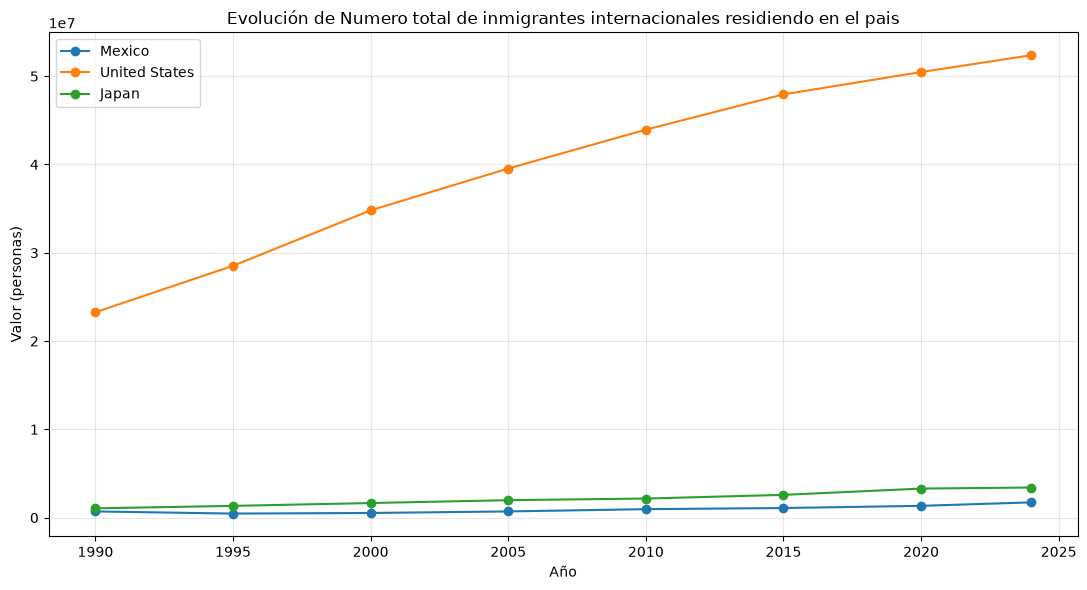

In [17]:
# Pregunta 8
paises_p8 = ["Mexico", "United States", "Japan"]
datos_p8 = df_paises[df_paises["entity"].isin(paises_p8)].dropna(subset=["valor"])

plt.figure(figsize=(11, 6))
for pais in paises_p8:
    serie = datos_p8[datos_p8["entity"].eq(pais)].sort_values("year")
    plt.plot(serie["year"], serie["valor"], marker="o", label=pais)

plt.title(f"Evolución de {config['descripcion']}")
plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:** Estados Unidos mantiene valores muy superiores a México y Japón durante todo el periodo. Estados Unidos y Japón muestran un crecimiento sostenido; México presenta una disminución inicial y después un crecimiento. La escala de Estados Unidos hace que las variaciones de los otros dos parezcan pequeñas en la misma gráfica.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

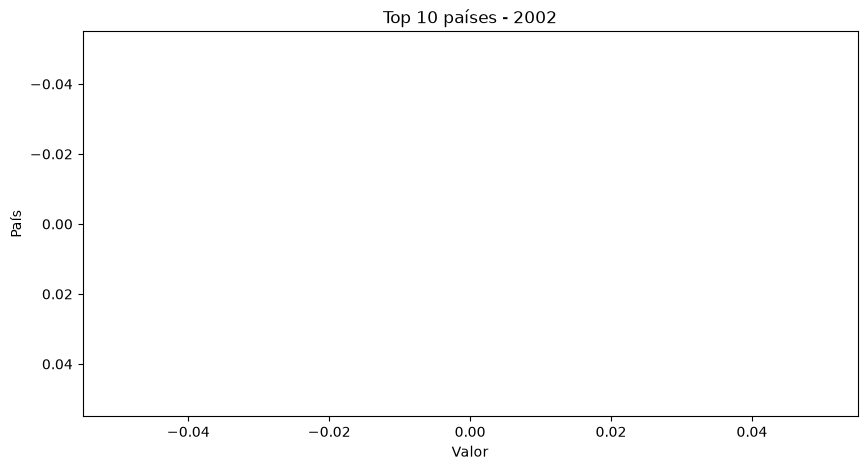

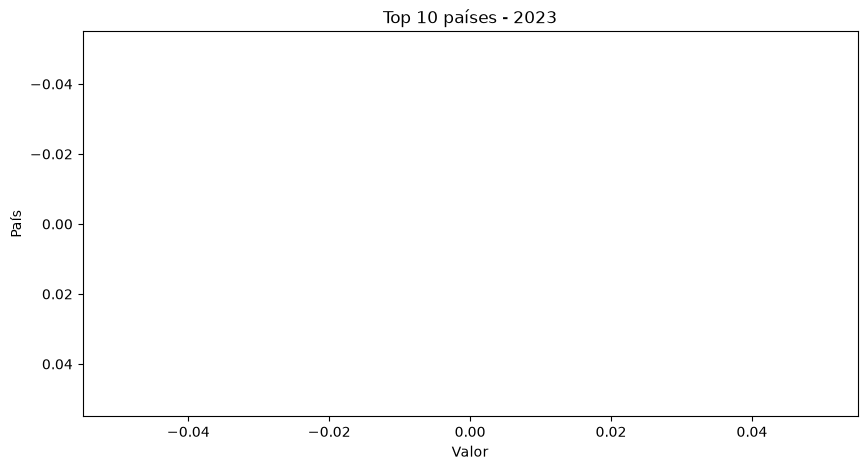

In [18]:
# Pregunta 9

df_paises = df[df[config["filtro_paises"]].notnull()]

# Gráfica 2002
anio_consultado = 2002

top = (
    df_paises[df_paises["year"] == anio_consultado]
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top["entity"], top["valor"])

plt.xlabel("Valor")
plt.ylabel("País")
plt.title("Top 10 países - 2002")

plt.gca().invert_yaxis()
plt.show()


# Gráfica 2023
anio_consultado = 2023

top = (
    df_paises[df_paises["year"] == anio_consultado]
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top["entity"], top["valor"])

plt.xlabel("Valor")
plt.ylabel("País")
plt.title("Top 10 países - 2023")

plt.gca().invert_yaxis()
plt.show()

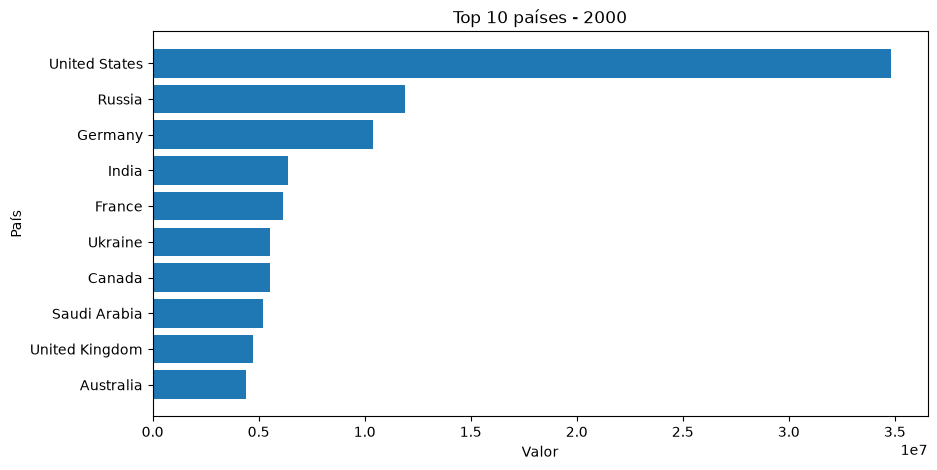

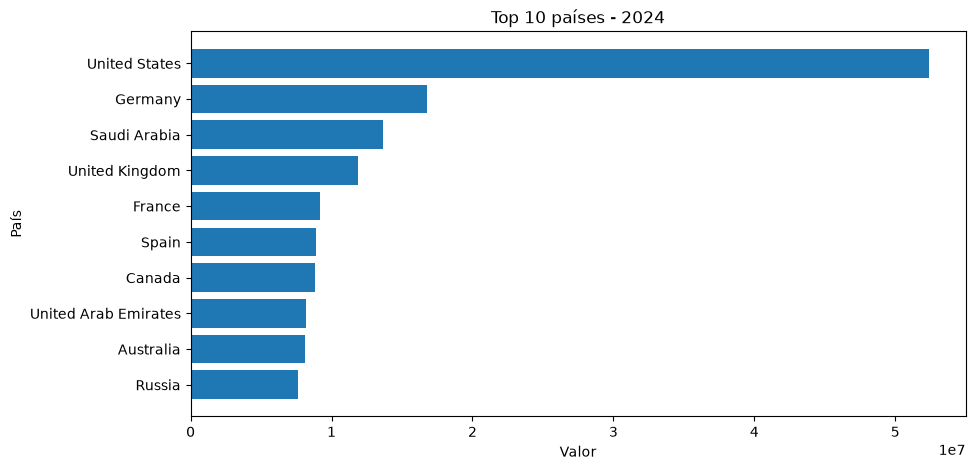

In [19]:
# Pregunta 9

df_paises = df[df[config["filtro_paises"]].notnull()]

# Gráfica 2002
anio_consultado = 2000

top = (
    df_paises[df_paises["year"] == anio_consultado]
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top["entity"], top["valor"])

plt.xlabel("Valor")
plt.ylabel("País")
plt.title("Top 10 países - 2000")

plt.gca().invert_yaxis()
plt.show()


# Gráfica 2023
anio_consultado = 2024

top = (
    df_paises[df_paises["year"] == anio_consultado]
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top["entity"], top["valor"])

plt.xlabel("Valor")
plt.ylabel("País")
plt.title("Top 10 países - 2024")

plt.gca().invert_yaxis()
plt.show()

**Interpretación:** El dataset no contiene exactamente los años 2002 ni 2023; por eso se utilizaron los años disponibles más cercanos, 2000 y 2024. Estados Unidos se mantuvo en el primer lugar, Alemania subió al segundo y Arabia Saudita avanzó varias posiciones. También cambiaron los países que completan el Top 10, lo que refleja movimientos en la distribución de la población inmigrante.

## 5. Conclusión general

En este trabajo se analizó la cantidad de inmigrantes que viven en diferentes países. Los resultados muestran que existen diferencias muy grandes entre ellos. Estados Unidos tuvo el valor más alto en el año más reciente, mientras que países pequeños como Tuvalu tuvieron valores mucho menores. En total, se encontraron 228 países con información.

También se compararon México y Canadá, así como varios países de diferentes regiones. Canadá tuvo valores mayores que México durante el periodo revisado. Además, el promedio de los países de Latinoamérica seleccionados fue mayor que el promedio de los países de Asia seleccionados.

Al revisar los cambios a través del tiempo, India mostró una disminución en la cantidad de inmigrantes, mientras que México aumentó 146.05% entre 1990 y 2024. Las operaciones estadísticas y las gráficas ayudaron a entender mejor estas diferencias y a observar cómo cambiaron los países en los años analizados.

En general, el dataset permitió conocer mejor la distribución de los inmigrantes y comparar países, años y grupos. Sin embargo, los datos representan cantidades totales y no explican por qué ocurrieron estos cambios. Para realizar un análisis más completo sería necesario compararlos con la población total, la economía y otros factores sociales.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
